## Imports

In [102]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
import pickle
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing
import matplotlib
matplotlib.use('Agg')
try:
    from numba import njit
    print("Numba available — JIT compilation enabled.")
except ImportError:
    print("Numba not available — running in pure Python mode.")
    def njit(fn=None, **kwargs):
        if fn is not None:
            return fn
        return lambda f: f

Numba available — JIT compilation enabled.


In [119]:
%matplotlib inline

## Data & preprocessing

In [103]:
freq      = "seasonal"
df        = pd.read_csv(f'../data/covid_{freq}.csv', parse_dates=['date'])
block_cov = pd.read_csv(f'../data/block_cov_{freq}.csv')
block_cov = block_cov.set_index(['country', 'time_block'])

all_countries = df['country'].unique()
cont_map  = df.drop_duplicates('country').set_index('country')['continent'].to_dict()
cont_list = sorted(set(cont_map.values()))
cont_idx  = {c: i for i, c in enumerate(cont_list)}
n_cont    = len(cont_list)

all_blocks = sorted(df['time_block'].unique())
n_blocks   = len(all_blocks)
block_idx  = {b: i for i, b in enumerate(all_blocks)}

sigma2 = 0.03

print(df.columns.tolist())
print(block_cov.columns.tolist())

['country', 'date', 'log_cases', 'continent', 'pc1', 'pc2', 'time_block']
['stringency_lag', 'vac_lag', 'log_vac_lag']


## Country-level train/holdout split

Hold out 20% of countries entirely from EM training.
Holdout countries are evaluated using `mu0_prior` as initial state and
`theta_by_continent` for the continent effect.


In [104]:
np.random.seed(42)
n_holdout         = max(1, int(len(all_countries) * 0.2))
holdout_countries = set(np.random.choice(all_countries, size=n_holdout, replace=False))
train_countries   = [c for c in all_countries if c not in holdout_countries]

print(f"Total countries:   {len(all_countries)}")
print(f"Train countries:   {len(train_countries)}")
print(f"Holdout countries: {len(holdout_countries)}")
print(f"Holdout set: {sorted(holdout_countries)}")

# EM operates only on train countries
countries = np.array(train_countries)

Total countries:   121
Train countries:   97
Holdout countries: 24
Holdout set: ['Afghanistan', 'Austria', 'Belarus', 'Belgium', 'Burundi', 'Croatia', 'Dominica', 'Estonia', 'Finland', 'Germany', 'Ghana', 'Guatemala', 'Iran', 'Jordan', 'Kuwait', 'Laos', 'Luxembourg', 'Malta', 'Panama', 'Paraguay', 'South Korea', 'Sweden', 'Togo', 'Uruguay']


## Helper functions

In [105]:
def _build_cov_arrays():
    df_by_country = {}
    str_arr, vac_arr = {}, {}
    for c in all_countries:   # build for ALL countries including holdout
        df_c = df[df['country'] == c].sort_values('date').reset_index(drop=True)
        df_by_country[c] = df_c
        T = len(df_c)
        sv = np.zeros(T); vv = np.zeros(T)
        for i, row in df_c.iterrows():
            key = (c, row['time_block'])
            if key in block_cov.index:
                sv[i] = float(block_cov.loc[key, 'stringency_lag'])
                vv[i] = float(block_cov.loc[key, 'log_vac_lag'])
        str_arr[c] = sv
        vac_arr[c] = vv
    return df_by_country, str_arr, vac_arr

df_by_country, _str_arr, _vac_arr = _build_cov_arrays()


def compute_mu_t_c(c, beta, theta_c, delta=None):
    df_c = df_by_country[c]
    T    = len(df_c)
    U_c1 = float(df_c['pc1'].iloc[0])
    U_c2 = float(df_c['pc2'].iloc[0])
    sv   = _str_arr[c]; vv = _vac_arr[c]
    X = np.column_stack([np.ones(T), np.full(T, U_c1), np.full(T, U_c2), sv, vv])
    if delta is None:
        return X @ beta + theta_c
    else:
        blocks = df_c['time_block'].values
        D_mat  = np.array([delta.get(b, np.zeros(5)) for b in blocks])
        return np.sum(X * (beta + D_mat), axis=1) + theta_c


def get_block_covariates(country, time_block):
    key = (country, time_block)
    if key in block_cov.index:
        return (float(block_cov.loc[key, 'stringency_lag']),
                float(block_cov.loc[key, 'log_vac_lag']))
    return 0.0, 0.0

## Kalman filter & RTS smoother

In [106]:
@njit
def kalman_filter_scalar(Y, log_pc, mu_seq, tau2, mu_s_1, Sigma_s_1, sigma2):
    T      = len(Y)
    mu_f   = np.zeros(T); Sigma_f = np.zeros(T)
    mu_p   = np.zeros(T); Sigma_p = np.zeros(T)
    log_ml = 0.0
    for t in range(T):
        if t == 0:
            mu_p[t]    = mu_s_1
            Sigma_p[t] = Sigma_s_1
        else:
            mu_p[t]    = mu_f[t-1] + mu_seq[t]
            Sigma_p[t] = Sigma_f[t-1] + sigma2
        innov      = Y[t] - log_pc - mu_p[t]
        H_t        = Sigma_p[t] + tau2
        K_t        = Sigma_p[t] / H_t
        mu_f[t]    = mu_p[t]  + K_t * innov
        Sigma_f[t] = (1.0 - K_t) * Sigma_p[t]
        log_ml    += -0.5 * (np.log(2.0 * np.pi * H_t) + innov**2 / H_t)
    return mu_f, Sigma_f, mu_p, Sigma_p, log_ml


@njit
def rts_smoother_scalar(mu_f, Sigma_f, mu_p, Sigma_p):
    T             = len(mu_f)
    mu_s          = mu_f.copy(); Sigma_s = Sigma_f.copy()
    Sigma_s_cross = np.zeros(T - 1)
    for t in range(T - 2, -1, -1):
        G_t              = Sigma_f[t] / Sigma_p[t + 1]
        mu_s[t]          = mu_f[t]  + G_t * (mu_s[t+1]  - mu_p[t+1])
        Sigma_s[t]       = Sigma_f[t] + G_t**2 * (Sigma_s[t+1] - Sigma_p[t+1])
        Sigma_s_cross[t] = G_t * Sigma_s[t+1]
    return mu_s, Sigma_s, Sigma_s_cross


def make_companion_matrix(rho_vec):
    p = len(rho_vec); d = p + 1
    A = np.zeros((d, d))
    A[0, 0] = 1.0; A[0, 1:] = rho_vec; A[1, 1:] = rho_vec
    for k in range(2, d):
        A[k, k-1] = 1.0
    return A


@njit
def kalman_filter_arp(Y, log_pc, mu_seq, tau2, mu_s_1, Sigma_s_1, A, Q, sigma2):
    d  = A.shape[0]; T = len(Y)
    mu_f  = np.zeros((T, d)); Sig_f = np.zeros((T, d, d))
    mu_p  = np.zeros((T, d)); Sig_p = np.zeros((T, d, d))
    log_ml = 0.0
    for t in range(T):
        if t == 0:
            mu_p[t, 0] = mu_s_1
            for i in range(d):
                Sig_p[t, i, i] = Sigma_s_1
        else:
            for i in range(d):
                s = 0.0
                for j in range(d):
                    s += A[i, j] * mu_f[t-1, j]
                mu_p[t, i] = s
            mu_p[t, 0] += mu_seq[t]; mu_p[t, 1] += mu_seq[t]
            for i in range(d):
                for j in range(d):
                    s = 0.0
                    for k in range(d):
                        for l in range(d):
                            s += A[i, k] * Sig_f[t-1, k, l] * A[j, l]
                    Sig_p[t, i, j] = s + Q[i, j]
        innov = Y[t] - log_pc - mu_p[t, 0]
        H_t   = Sig_p[t, 0, 0] + tau2
        if H_t < 1e-8: H_t = 1e-8
        for i in range(d):
            K_i = Sig_p[t, i, 0] / H_t
            mu_f[t, i] = mu_p[t, i] + K_i * innov
        for i in range(d):
            K_i = Sig_p[t, i, 0] / H_t
            for j in range(d):
                Sig_f[t, i, j] = Sig_p[t, i, j] - K_i * Sig_p[t, 0, j]
        log_ml += -0.5 * (np.log(2.0 * np.pi * H_t) + innov**2 / H_t)
    return mu_f, Sig_f, mu_p, Sig_p, log_ml


@njit
def rts_smoother_arp(mu_f, Sig_f, mu_p, Sig_p, A):
    T  = mu_f.shape[0]; d = mu_f.shape[1]
    mu_s        = mu_f.copy(); Sig_s = Sig_f.copy()
    Sig_s_cross = np.zeros((T - 1, d, d))
    for t in range(T - 2, -1, -1):
        Sig_p_reg = Sig_p[t+1].copy()
        for i in range(d): Sig_p_reg[i, i] += 1e-10
        ASf = np.zeros((d, d))
        for i in range(d):
            for j in range(d):
                s = 0.0
                for k in range(d): s += A[i, k] * Sig_f[t, j, k]
                ASf[i, j] = s
        Gt_T = np.linalg.solve(Sig_p_reg, ASf); G_t = Gt_T.T
        diff = mu_s[t+1] - mu_p[t+1]
        for i in range(d):
            s = 0.0
            for j in range(d): s += G_t[i, j] * diff[j]
            mu_s[t, i] = mu_f[t, i] + s
        dS = Sig_s[t+1] - Sig_p[t+1]; GdS = np.zeros((d, d))
        for i in range(d):
            for j in range(d):
                s = 0.0
                for k in range(d): s += G_t[i, k] * dS[k, j]
                GdS[i, j] = s
        for i in range(d):
            for j in range(d):
                s = 0.0
                for k in range(d): s += GdS[i, k] * G_t[j, k]
                Sig_s[t, i, j] = Sig_f[t, i, j] + s
        # Sig_s_cross[t][a,b] = Cov(X_{t+1}[a], X_t[b]) = G_t @ Sig_s[t+1]
        for i in range(d):
            for j in range(d):
                s = 0.0
                for k in range(d): s += G_t[i, k] * Sig_s[t+1, k, j]
                Sig_s_cross[t, i, j] = s
    return mu_s, Sig_s, Sig_s_cross


def _warmup_numba():
    print("Warming up Numba JIT (one-time compile)...")
    _Y  = np.random.randn(5).astype(np.float64); _mu = np.zeros(5)
    kalman_filter_scalar(_Y, 0.0, _mu, 0.01, 0.0, 0.03, 0.03)
    rts_smoother_scalar(np.zeros(5), np.ones(5)*0.03, np.zeros(5), np.ones(5)*0.03)
    for _p in range(1, 5):
        _rv = np.zeros(_p); _A = make_companion_matrix(_rv); _d = _p + 1
        _Q  = np.zeros((_d, _d))
        _Q[0,0]=0.03; _Q[0,1]=0.03; _Q[1,0]=0.03; _Q[1,1]=0.03
        _mf,_sf,_mp,_sp,_ = kalman_filter_arp(_Y[:_p+1],0.0,_mu[:_p+1],0.01,0.0,0.03,_A,_Q,0.03)
        rts_smoother_arp(_mf,_sf,_mp,_sp,_A)
    print("Numba JIT ready.")

_warmup_numba()

Warming up Numba JIT (one-time compile)...
Numba JIT ready.


## E-step

**Update 1:** `alpha_c` removed. `log_pc = 0`. Initial state = `mu0_c[country]`.


In [55]:
def e_step(df, mu0_c, beta, theta, tau2, sigma2=0.03, delta=None, rho_vec=None):
    results = {}; log_ml = 0.0
    arp = (rho_vec is not None and len(rho_vec) > 0)

    if arp:
        A = make_companion_matrix(rho_vec)
        p = len(rho_vec); d = p + 1
        e = np.zeros(d); e[0]=1.0; e[1]=1.0
        Q = sigma2 * np.outer(e, e)

    for country in countries:
        df_c   = df_by_country[country]
        Y      = df_c['log_cases'].values.astype(np.float64)
        mu_seq = compute_mu_t_c(country, beta, theta[country], delta=delta)
        mu_s_1 = mu0_c[country]; Sigma_s_1 = sigma2

        if arp:
            mu_f_p, Sig_f_p, mu_p_p, Sig_p_p, lml = kalman_filter_arp(
                Y, 0.0, mu_seq, tau2, mu_s_1, Sigma_s_1, A, Q, sigma2)
            mu_s_p, Sig_s_p, Sig_s_cross_p = rts_smoother_arp(
                mu_f_p, Sig_f_p, mu_p_p, Sig_p_p, A)
            ES  = mu_s_p[:, 0]
            ES2 = Sig_s_p[:, 0, 0] + mu_s_p[:, 0]**2
            ESS = Sig_s_cross_p[:, 0, 0] + mu_s_p[1:, 0] * mu_s_p[:-1, 0]
            mu_f_sc = mu_f_p[:, 0]; Sigma_f = Sig_f_p[:, 0, 0]
            mu_p_sc = mu_p_p[:, 0]; Sigma_p = Sig_p_p[:, 0, 0]
        else:
            mu_f_sc, Sigma_f, mu_p_sc, Sigma_p, lml = kalman_filter_scalar(
                Y, 0.0, mu_seq, tau2, mu_s_1, Sigma_s_1, sigma2)
            mu_s, Sigma_s, Sigma_s_cross = rts_smoother_scalar(
                mu_f_sc, Sigma_f, mu_p_sc, Sigma_p)
            ES  = mu_s; ES2 = Sigma_s + mu_s**2
            ESS = Sigma_s_cross + mu_s[1:] * mu_s[:-1]
            mu_s_p=Sig_s_p=mu_p_p=Sig_p_p=Sig_s_cross_p=mu_f_p=Sig_f_p=None

        log_ml += lml
        results[country] = {
            'ES': ES, 'ES2': ES2, 'ESS': ESS, 'Y': Y, 'mu_seq': mu_seq,
            'PC_c1': float(df_c['pc1'].iloc[0]), 'PC_c2': float(df_c['pc2'].iloc[0]),
            'blocks': df_c['time_block'].tolist(), 'dates': df_c['date'].tolist(),
            'mu_f': mu_f_sc, 'Sigma_f': Sigma_f, 'mu_p': mu_p_sc, 'Sigma_p': Sigma_p,
            'mu_s_p': mu_s_p, 'Sig_s_p': Sig_s_p,
            'mu_p_p': mu_p_p, 'Sig_p_p': Sig_p_p,
            'Sig_s_cross_p': Sig_s_cross_p, 'mu_f_p': mu_f_p, 'Sig_f_p': Sig_f_p,
        }

    return results, log_ml

## M-step

**Update:** `alpha_c` removed; tau2 uses raw Y; hierarchical `mu0_c` MAP update.


In [107]:
def m_step(df, results, mu0_c, tau2, mu0_prior, sigma0_sq,
           lam=1.0, delta=None, lam_delta=5.0, rho_vec=None):
    arp = (rho_vec is not None and len(rho_vec) > 0)
    p   = len(rho_vec) if arp else 0

    # ── Step 1: beta / delta / theta ─────────────────────────────────────────
    rows_y, rows_x = [], []
    for country in countries:
        res  = results[country]; df_c = df_by_country[country]; T = len(df_c)
        D    = res['mu_s_p'][:, 1] if (arp and res['mu_s_p'] is not None)                else res['ES'][1:] - res['ES'][:-1]
        sv   = _str_arr[country]; vv = _vac_arr[country]
        U_c1 = res['PC_c1'];      U_c2 = res['PC_c2']
        cont_dummy = np.zeros(n_cont)
        cont_dummy[cont_idx[cont_map[country]]] = 1.0
        blocks = df_c['time_block'].values

        for t in range(T - 1):
            X_t = np.array([1., U_c1, U_c2, sv[t+1], vv[t+1]])
            if delta is None:
                rows_x.append(np.concatenate([X_t, cont_dummy]))
            else:
                bi = block_idx[blocks[t+1]]; db = np.zeros(n_blocks * 5)
                db[bi*5: bi*5+5] = X_t
                rows_x.append(np.concatenate([X_t, db, cont_dummy]))
            if arp and res['mu_s_p'] is not None:
                lag_sum = sum(rho_vec[k]*D[t-k] for k in range(p) if t-k >= 0)
                rows_y.append(D[t+1] - lag_sum)
            else:
                rows_y.append(D[t])

    y_reg = np.array(rows_y); X_reg = np.array(rows_x)

    if delta is None:
        ridge = Ridge(alpha=lam, fit_intercept=False); ridge.fit(X_reg, y_reg)
        coefs = ridge.coef_; beta_new = coefs[:5]; theta_raw = coefs[5:].copy()
        delta_new = None
    else:
        n_b=5; n_d=n_blocks*5; n_t=n_cont
        penalty = np.concatenate([np.full(n_b,lam), np.full(n_d,lam_delta), np.full(n_t,lam)])
        scale   = np.sqrt(penalty)
        ridge   = Ridge(alpha=1.0, fit_intercept=False); ridge.fit(X_reg/scale, y_reg)
        coefs   = ridge.coef_ / scale; beta_new = coefs[:n_b]
        delta_raw = coefs[n_b: n_b+n_d]
        delta_new = {b: delta_raw[block_idx[b]*5: block_idx[b]*5+5].copy() for b in all_blocks}
        theta_raw = coefs[n_b+n_d:].copy()

    theta_raw -= theta_raw.mean()
    # Store by country (used in e_step for train countries)
    theta_new = {c: float(theta_raw[cont_idx[cont_map[c]]]) for c in countries}
    # Store by continent (used in holdout/proper eval — fixes the key bug)
    theta_by_continent = {cont: float(theta_raw[i]) for cont, i in cont_idx.items()}

    # ── Step 2: tau2 ──────────────────────────────────────────────────────────
    tau2_num, N_tau = 0.0, 0
    for country in countries:
        res = results[country]; Y = res['Y']
        tau2_num += float(np.sum(Y**2 - 2*Y*res['ES'] + res['ES2']))
        N_tau    += len(Y)
    tau2_new = max(tau2_num / N_tau, 1e-6)

    # ── Step 3: mu0_c MAP ─────────────────────────────────────────────────────
    mu0_c_new = {}
    for country in countries:
        ES0   = results[country]['ES'][0]
        num   = ES0/sigma2 + mu0_prior/sigma0_sq
        denom = 1.0/sigma2 + 1.0/sigma0_sq
        mu0_c_new[country] = float(num/denom)

    # ── Step 4: mu0_prior, sigma0_sq MLE ─────────────────────────────────────
    mu0_vals      = np.array([mu0_c_new[c] for c in countries])
    mu0_prior_new = float(mu0_vals.mean())
    sigma0_sq_new = max(float(mu0_vals.var()), 1e-6)

    # ── Step 5: rho_vec — exact EM ───────────────────────────────────────────
    # Normal equations from Q-function:
    #   mat_A[i,j] = sum_t E[D_{t-i} * D_{t-j} | Y]
    #              = sum_t { Sig_s_p[t-1, i, j] + E[D_{t-i}]*E[D_{t-j}] }
    #   vec_b[k]   = sum_t { E[D_t*D_{t-k}|Y] - mu_t * E[D_{t-k}|Y] }
    #   E[D_t*D_{t-k}|Y] = Sig_s_cross_p[t-1, 1, k] + E[D_t]*E[D_{t-k}]
    #
    # State indices: X_t[1]=D_t, X_t[k]=D_{t-k+1} => X_{t-1}[k]=D_{t-k}
    # Sig_s_cross_p[t-1][a,b] = Cov(X_t[a], X_{t-1}[b])
    rho_vec_new = rho_vec
    if arp and p > 0:
        mat_A = np.zeros((p, p)); vec_b = np.zeros(p)

        for country in countries:
            res           = results[country]
            mu_s_p        = res['mu_s_p']
            Sig_s_p       = res['Sig_s_p']
            Sig_s_cross_p = res['Sig_s_cross_p']
            mu_seq        = res['mu_seq']
            if mu_s_p is None: continue

            # mat_A[i,j] = sum_t E[D_{t-i} * D_{t-j} | Y]  (lag indices 1..p)
            mat_A += (
                np.sum(Sig_s_p[:-1, 1:p+1, 1:p+1], axis=0)       # Cov terms
                + mu_s_p[:-1, 1:p+1].T @ mu_s_p[:-1, 1:p+1]      # mean^2 terms
            )

            # E[D_t * D_{t-k} | Y] = Sig_s_cross_p[t-1, 1, k] + E[D_t]*E[D_{t-k}]
            E_Dt_Dtk = (
                Sig_s_cross_p[:, 1:p+1, 1]                        # Cov(D_t, D_{t-k})
                + mu_s_p[1:, 1:2] * mu_s_p[:-1, 1:p+1]           # E[D_t]*E[D_{t-k}]
            )  # shape (T-1, p)

            # vec_b[k] = sum_t { E[D_t*D_{t-k}] - mu_t * E[D_{t-k}] }
            vec_b += np.sum(E_Dt_Dtk - mu_seq[1:, None] * mu_s_p[:-1, 1:p+1], axis=0)

        rho_vec_new = np.linalg.solve(mat_A + 1e-6*np.eye(p), vec_b)

    return (beta_new, delta_new, theta_new, theta_by_continent,
            tau2_new, mu0_c_new, mu0_prior_new, sigma0_sq_new, rho_vec_new)

## EM runner

In [108]:
def run_EM(df, label, n_iter=1000, lam=1.0, lam_delta=5.0,
           tol=1e-4, rho_vec_init=None, use_delta=False, verbose=True):
    arp = (rho_vec_init is not None and len(rho_vec_init) > 0)
    p   = len(rho_vec_init) if arp else 0

    if verbose:
        print(f"\n{'='*60}\n  {label}\n  p={p}\n{'='*60}")

    beta      = np.zeros(5)
    delta     = ({b: np.zeros(5) for b in all_blocks} if use_delta else None)
    theta     = {c: 0.0 for c in countries}
    theta_by_continent = {cont: 0.0 for cont in cont_list}
    tau2      = 0.01
    rho_vec   = rho_vec_init.copy() if arp else None
    mu0_prior = 0.0; sigma0_sq = 1.0
    mu0_c     = {c: 0.0 for c in countries}
    log_mls   = []

    for it in range(n_iter):
        results, log_ml = e_step(df, mu0_c, beta, theta, tau2,
                                  sigma2=sigma2, delta=delta, rho_vec=rho_vec)
        log_mls.append(log_ml)

        (beta, delta, theta, theta_by_continent,
         tau2, mu0_c, mu0_prior, sigma0_sq,
         rho_vec) = m_step(df, results, mu0_c, tau2, mu0_prior, sigma0_sq,
                           lam=lam, delta=delta, lam_delta=lam_delta, rho_vec=rho_vec)

        if verbose and (it % 50 == 0 or it == n_iter-1):
            rho_str = (f"  rho={np.round(rho_vec,4).tolist()}" if arp else "")
            print(f"  iter {it+1:3d}  log_ml={log_ml:10.2f}  tau2={tau2:.5f}"
                  f"  mu0={mu0_prior:.3f}  sig0sq={sigma0_sq:.4f}{rho_str}")

        if it > 0 and abs(log_mls[-1] - log_mls[-2]) < tol:
            if verbose: print(f"  Converged at iter {it+1}")
            break

    return {
        'label': label, 'p': p, 'results': results,
        'beta': beta, 'delta': delta,
        'theta': theta,
        'theta_by_continent': theta_by_continent,
        'tau2': tau2,
        'mu0_c': mu0_c, 'mu0_prior': mu0_prior, 'sigma0_sq': sigma0_sq,
        'rho_vec': rho_vec, 'log_mls': log_mls, 'final_log_ml': log_mls[-1],
    }

## Parallel runner (to speed up model fitting)

In [110]:
def _run_em_worker(kwargs):
    return run_EM(**kwargs, verbose=False)


def run_all_models_parallel(df, model_specs, max_workers=None):
    if max_workers is None:
        max_workers = min(len(model_specs), multiprocessing.cpu_count())
    print(f"Launching {len(model_specs)} models on {max_workers} workers...")
    jobs = [dict(df=df, **spec) for spec in model_specs]
    results_map = {}
    with ProcessPoolExecutor(max_workers=max_workers) as pool:
        future_to_idx = {pool.submit(_run_em_worker, job): i for i, job in enumerate(jobs)}
        for future in as_completed(future_to_idx):
            i = future_to_idx[future]; label = model_specs[i]['label']
            try:
                model = future.result(); results_map[i] = model
                rho_str = (f"  rho={np.round(model['rho_vec'],4).tolist()}"
                           if model['rho_vec'] is not None else "")
                print(f"  ✓ {label:40s}  log_ml={model['final_log_ml']:10.2f}"
                      f"  tau2={model['tau2']:.5f}"
                      f"  mu0={model['mu0_prior']:.3f}"
                      f"  sig0sq={model['sigma0_sq']:.4f}{rho_str}")
            except Exception as e:
                print(f"  ✗ {label} FAILED: {e}"); results_map[i] = None
    return [results_map[i] for i in range(len(model_specs))]

## Fit models

| Model | p | use_delta |
|---|---|---|
| M0 | — | False |
| M1 | — | True |
| M2–M7 | 1–6 | True |


In [111]:
model_specs = [
    dict(label="M0 — baseline",             lam=1.0, use_delta=False, rho_vec_init=None),
    dict(label="M1 — +seasonal drift",      lam=1.0, lam_delta=5.0, use_delta=True, rho_vec_init=None),
] + [
    dict(label=f"M{p+1} — +AR({p}) increment",
         lam=1.0, lam_delta=5.0, use_delta=True, rho_vec_init=np.zeros(p))
    for p in range(1, 7)
]

all_models = run_all_models_parallel(df, model_specs)
m0 = all_models[0]; m1 = all_models[1]
ar_models = [m for m in all_models if m['p'] > 0]

Launching 8 models on 8 workers...
  ✓ M2 — +AR(1) increment                     log_ml=  -7287.82  tau2=0.04898  mu0=0.001  sig0sq=0.0000  rho=[0.7769]
  ✓ M3 — +AR(2) increment                     log_ml=  -6361.76  tau2=0.04065  mu0=0.001  sig0sq=0.0000  rho=[1.1784, -0.4838]
  ✓ M0 — baseline                             log_ml= -16570.61  tau2=0.27184  mu0=0.001  sig0sq=0.0000
  ✓ M4 — +AR(3) increment                     log_ml=  -6343.85  tau2=0.03920  mu0=0.001  sig0sq=0.0000  rho=[1.2588, -0.6612, 0.119]
  ✓ M5 — +AR(4) increment                     log_ml=  -6293.31  tau2=0.03674  mu0=0.001  sig0sq=0.0000  rho=[1.3954, -1.0816, 0.6118, -0.234]
  ✓ M6 — +AR(5) increment                     log_ml=  -6264.02  tau2=0.03796  mu0=0.001  sig0sq=0.0000  rho=[1.2802, -0.6827, -0.0193, 0.3053, -0.2177]
  ✓ M7 — +AR(6) increment                     log_ml=  -6251.86  tau2=0.03828  mu0=0.001  sig0sq=0.0000  rho=[1.2768, -0.7299, 0.1664, -0.0233, 0.092, -0.1356]
  ✓ M1 — +seasonal drift  

The first two lags are highly stable across all fitted models, suggesting that most temporal dependence is captured by an AR(2) structure with positive short-run momentum and a negative second-lag correction. Higher-order coefficients are much less stable and likely act as small adjustments to the same underlying dependence pattern rather than representing distinct interpretable effects.

## Performance table


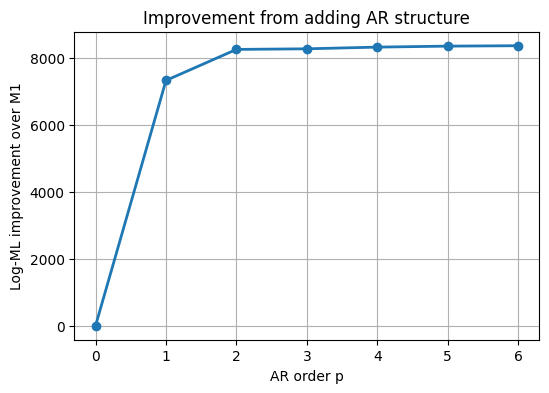

In [127]:
m1_logml = m1['final_log_ml']

ps = [0]
gain = [0]

for m in all_models:
    if m['rho_vec'] is not None:
        ps.append(len(m['rho_vec']))
        gain.append(m['final_log_ml'] - m1_logml)

plt.figure(figsize=(6,4))
plt.plot(ps, gain, marker='o', linewidth=2)

plt.xlabel('AR order p')
plt.ylabel('Log-ML improvement over M1')
plt.title('Improvement from adding AR structure')
plt.xticks(ps)
plt.grid(True)
plt.show()

Most of the improvement comes from introducing a second lag. Higher-order AR models continue to improve the fit, but with diminishing returns.

## Convergence & model selection plots

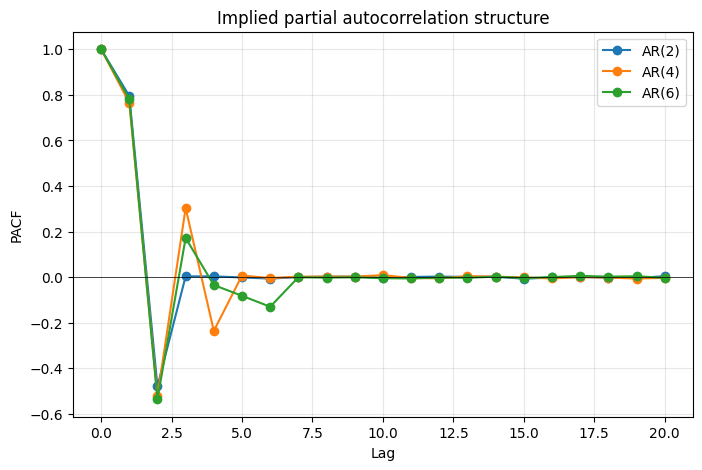

In [129]:
from statsmodels.tsa.arima_process import arma_acovf
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.arima_process import ArmaProcess

plt.figure(figsize=(8,5))

for p in [2,4,6]:

    model = next(m for m in all_models if m['p'] == p)

    rho = np.asarray(model['rho_vec'])

    ar_poly = np.r_[1, -rho]

    arma = ArmaProcess(ar_poly, [1])

    sim = arma.generate_sample(50000)

    pacf_vals = pacf(sim, nlags=20)

    plt.plot(
        range(len(pacf_vals)),
        pacf_vals,
        marker='o',
        label=f'AR({p})'
    )

plt.axhline(0, color='black', lw=0.5)
plt.xlabel("Lag")
plt.ylabel("PACF")
plt.title("Implied partial autocorrelation structure")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Although the higher-order AR coefficients vary across specifications, the implied partial autocorrelation structure remains broadly consistent. The dominant dependence is captured by a strong positive lag-1 effect and a negative lag-2 effect, while higher lags contribute relatively small corrections. This suggests that AR(2) captures the main temporal dynamics, with higher-order models providing incremental refinements rather than fundamentally different behavior.

Length = 11931


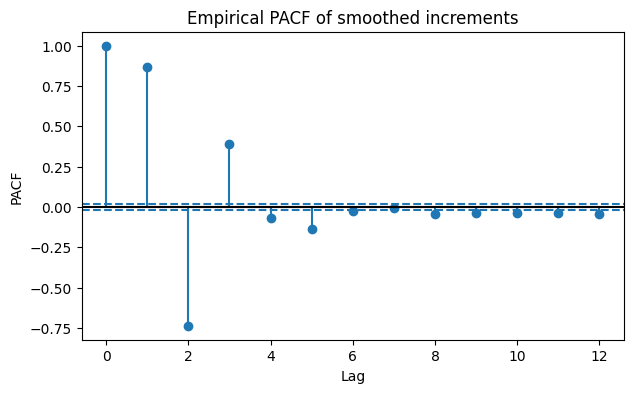

In [131]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import pacf

ar2 = next(m for m in all_models if m['p'] == 2)

all_D = []

for country, res in ar2['results'].items():

    # smoothed latent states
    ES = res['ES']

    # increments
    D = np.diff(ES)

    all_D.append(D)

D_all = np.concatenate(all_D)

print("Length =", len(D_all))

pacf_emp = pacf(D_all, nlags=12, method='ywm')

plt.figure(figsize=(7,4))
plt.stem(range(len(pacf_emp)), pacf_emp)
plt.axhline(0, color='black')

bound = 1.96 / np.sqrt(len(D_all))
plt.axhline(bound, linestyle='--')
plt.axhline(-bound, linestyle='--')

plt.xlabel("Lag")
plt.ylabel("PACF")
plt.title("Empirical PACF of smoothed increments")
plt.show()

This PACF provides evidence that AR(2) is a substantial improvement over AR(1), and it also gives some justification for why higher-order models continue to improve the likelihood. The strongest dependence is concentrated in the first three lags, while dependence beyond lag 3 appears much weaker.

## Stability check & nested model check

In [132]:
def check_stability(rho_vec):
    poly  = np.r_[-rho_vec[::-1], 1.0]; roots = np.roots(poly)
    print("  rho       =", np.round(rho_vec,4))
    print("  modulus   =", np.round(np.abs(roots),4))
    print("  stationary =", np.all(np.abs(roots)>1))

for m in all_models:
    if m['rho_vec'] is not None:
        print(m['label']); check_stability(m['rho_vec']); print()

def embedded_logml(model, rho_vec_fixed):
    _, log_ml = e_step(df=df, mu0_c=model['mu0_c'], beta=model['beta'],
                       theta=model['theta'], tau2=model['tau2'],
                       sigma2=sigma2, delta=model['delta'], rho_vec=rho_vec_fixed)
    return log_ml

ar1  = next(m for m in all_models if m['p']==1); rho1 = float(ar1['rho_vec'][0])
print("\n"+"="*60+"\nNESTED MODEL CHECK\n"+"="*60)
print(f"AR(1) fitted logML = {ar1['final_log_ml']:.4f}")
for m_arp in ar_models:
    if m_arp['p']<=1: continue
    emb_rho = np.array([rho1]+[0.0]*(m_arp['p']-1))
    ll_emb  = embedded_logml(m_arp, emb_rho)
    diff    = m_arp['final_log_ml'] - ll_emb
    status  = "✓ PASS" if diff+1e-6>=0 else "⚠ WARNING"
    print(f"AR({m_arp['p']})  fitted={m_arp['final_log_ml']:.4f}  "
          f"embedded={ll_emb:.4f}  diff={diff:.4f}  {status}")

M2 — +AR(1) increment
  rho       = [0.7769]
  modulus   = [1.2871]
  stationary = True

M3 — +AR(2) increment
  rho       = [ 1.1784 -0.4838]
  modulus   = [1.4377 1.4377]
  stationary = True

M4 — +AR(3) increment
  rho       = [ 1.2588 -0.6612  0.119 ]
  modulus   = [2.9203 1.6966 1.6966]
  stationary = True

M5 — +AR(4) increment
  rho       = [ 1.3954 -1.0816  0.6118 -0.234 ]
  modulus   = [1.5214 1.5214 1.3588 1.3588]
  stationary = True

M6 — +AR(5) increment
  rho       = [ 1.2802 -0.6827 -0.0193  0.3053 -0.2177]
  modulus   = [1.646  1.3357 1.3357 1.2508 1.2508]
  stationary = True

M7 — +AR(6) increment
  rho       = [ 1.2768 -0.7299  0.1664 -0.0233  0.092  -0.1356]
  modulus   = [1.735  1.735  1.2978 1.2978 1.2059 1.2059]
  stationary = True


NESTED MODEL CHECK
AR(1) fitted logML = -7287.8150
AR(2)  fitted=-6361.7643  embedded=-7387.2841  diff=1025.5198  ✓ PASS
AR(3)  fitted=-6343.8464  embedded=-7396.3691  diff=1052.5227  ✓ PASS
AR(4)  fitted=-6293.3104  embedded=-7460.979

## Diagnostics

TEMPORAL HOLDOUT  (train 80% / test 20%)

Re-fitting 7 models on training time steps …
Done.

Temporal holdout results (97 train countries, last 20% of time):
Model  p   RMSE  PI width  Coverage (95%)
   M1  0 0.9407    2.1926          0.7963
AR(1)  1 0.6080    1.5377          0.8796
AR(2)  2 0.5813    1.5992          0.9287
AR(3)  3 0.5849    1.6073          0.9299
AR(4)  4 0.5857    1.6125          0.9303
AR(5)  5 0.5805    1.6072          0.9303
AR(6)  6 0.5787    1.6026          0.9307


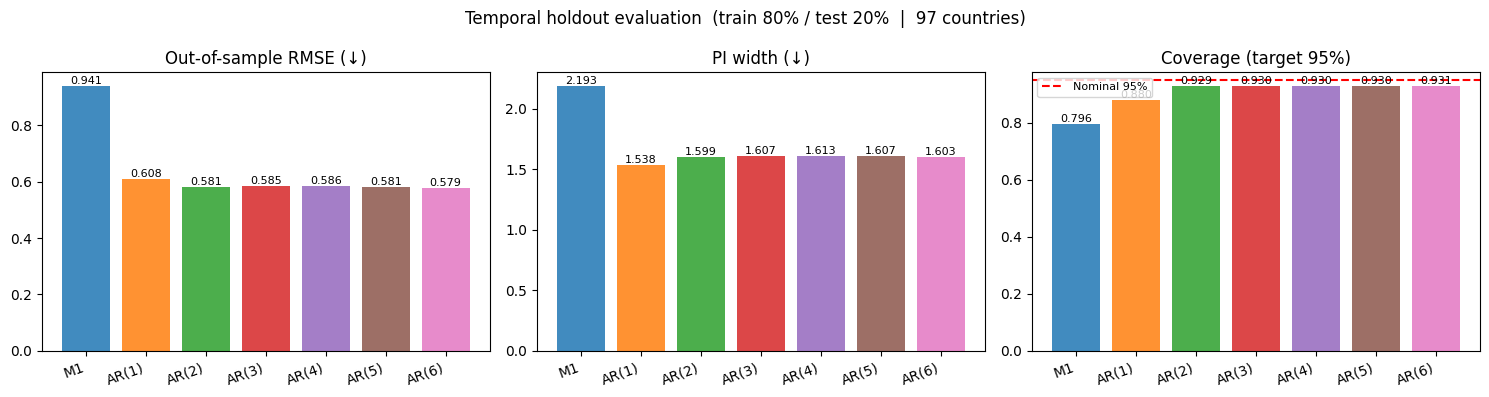

Saved ../data/temporal_holdout_eval_seasonal.png

COUNTRY HOLDOUT  (24 countries withheld from EM)
Holdout set: ['Afghanistan', 'Austria', 'Belarus', 'Belgium', 'Burundi', 'Croatia', 'Dominica', 'Estonia', 'Finland', 'Germany', 'Ghana', 'Guatemala', 'Iran', 'Jordan', 'Kuwait', 'Laos', 'Luxembourg', 'Malta', 'Panama', 'Paraguay', 'South Korea', 'Sweden', 'Togo', 'Uruguay']

Country holdout results (24 countries, full time series):
Model  p   RMSE  PI width  Coverage (95%)
   M1  0 0.7215    2.1852          0.8884
AR(1)  1 0.4571    1.5279          0.9254
AR(2)  2 0.4204    1.5873          0.9499
AR(3)  3 0.4176    1.5952          0.9496
AR(4)  4 0.4134    1.6002          0.9506
AR(5)  5 0.4136    1.5948          0.9496
AR(6)  6 0.4138    1.5903          0.9489


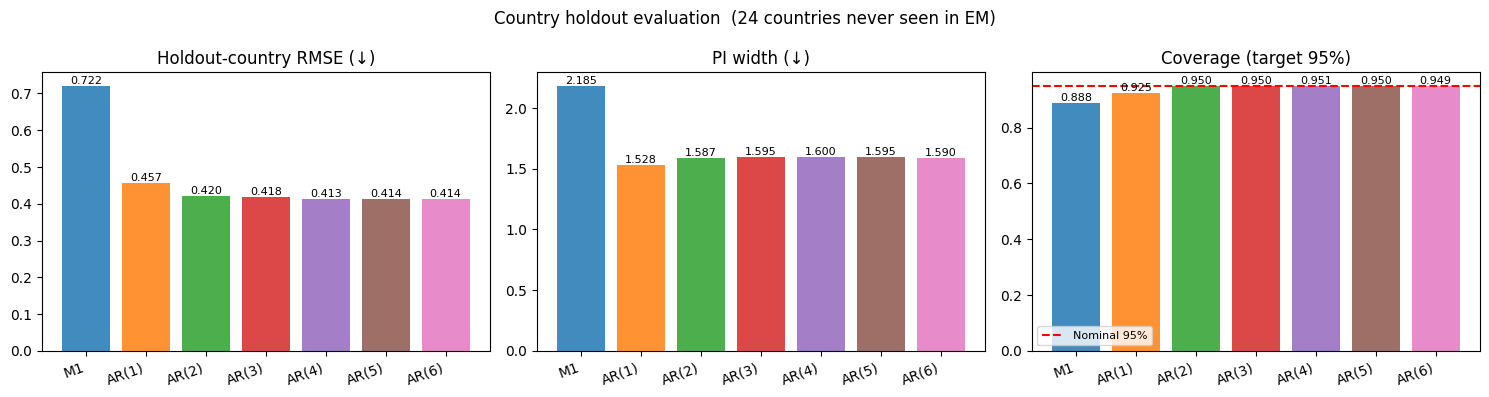

Saved ../data/country_holdout_eval_seasonal.png


COMBINED SUMMARY
Model  RMSE (temporal)  PI width (temporal)  Cov (temporal)  RMSE (country)  PI width (country)  Cov (country)
   M1           0.9407               2.1926          0.7963          0.7215              2.1852         0.8884
AR(1)           0.6080               1.5377          0.8796          0.4571              1.5279         0.9254
AR(2)           0.5813               1.5992          0.9287          0.4204              1.5873         0.9499
AR(3)           0.5849               1.6073          0.9299          0.4176              1.5952         0.9496
AR(4)           0.5857               1.6125          0.9303          0.4134              1.6002         0.9506
AR(5)           0.5805               1.6072          0.9303          0.4136              1.5948         0.9496
AR(6)           0.5787               1.6026          0.9307          0.4138              1.5903         0.9489


In [133]:
# ── Heldout forecasting & country evaluation ──────────────────────────────────
#
# Two evaluations are run here:
#
#   1. Temporal holdout  — last `test_frac` of each country's time series is
#      withheld.  Models are re-fitted on training time steps only; evaluation
#      uses the genuine predictive density p(Y_t | Y_{1:t-1}) for each test
#      observation.
#
#   2. Country holdout   — the 20 % of countries set aside before EM training
#      (`holdout_countries`) are never used during fitting.  Predictions for
#      these countries use the hierarchical prior (mu0_prior / sigma0_sq) as
#      the initial state and theta_by_continent for the continent effect.
#
# Both evaluations report RMSE, predictive-interval width, and empirical
# coverage for every model (M1, AR(1) … AR(6)).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ── shared settings ────────────────────────────────────────────────────────────
TEST_FRAC = 0.20
COVERAGE  = 0.95
Z_SCORE   = stats.norm.ppf((1 + COVERAGE) / 2)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

eval_models = [m1] + [m for m in all_models if m['p'] > 0]

# ══════════════════════════════════════════════════════════════════════════════
# 1. TEMPORAL HOLDOUT — re-fit on train time steps, evaluate on test time steps
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print(f"TEMPORAL HOLDOUT  (train {100*(1-TEST_FRAC):.0f}% / test {100*TEST_FRAC:.0f}%)")
print("=" * 70)

# -- 1a. Re-fit each model using only the first (1-TEST_FRAC) time steps ------
def _refit_on_train_time(base_model):
    train_records = []
    for country in countries:
        df_c  = df_by_country[country]
        t_cut = int(len(df_c) * (1 - TEST_FRAC))
        train_records.append(df_c.iloc[:t_cut])
    df_train = pd.concat(train_records, ignore_index=True)
    return run_EM(
        df          = df_train,
        label       = base_model['label'] + ' [train-time]',
        n_iter      = 500,
        lam         = 1.0,
        lam_delta   = 5.0,
        tol         = 1e-4,
        rho_vec_init = (np.zeros(base_model['p']) if base_model['p'] > 0 else None),
        use_delta   = (base_model['delta'] is not None),
        verbose     = False,
    )

print(f"\nRe-fitting {len(eval_models)} models on training time steps …")
train_time_models = [_refit_on_train_time(m) for m in eval_models]
print(f"Done.\n")

# -- 1b. Evaluate on held-out time steps --------------------------------------
temporal_rows = []

for m_tr, m_full in zip(train_time_models, eval_models):
    label = f"AR({m_full['p']})" if m_full['p'] > 0 else 'M1'

    rmse_num = 0.0; width_sum = 0.0; cov_sum = 0.0; n_total = 0

    for country in countries:
        df_c  = df_by_country[country]
        t_cut = int(len(df_c) * (1 - TEST_FRAC))

        Y, pred_mean, pred_var = _run_kalman_for_eval(m_tr, country, m_tr['tau2'])
        pred_std = np.sqrt(pred_var)

        Y_test   = Y[t_cut:]
        mu_test  = pred_mean[t_cut:]
        std_test = pred_std[t_cut:]
        lower    = mu_test - Z_SCORE * std_test
        upper    = mu_test + Z_SCORE * std_test
        n        = len(Y_test)

        rmse_num  += np.sum((Y_test - mu_test) ** 2)
        width_sum += np.sum(upper - lower)
        cov_sum   += np.sum((Y_test >= lower) & (Y_test <= upper))
        n_total   += n

    temporal_rows.append({
        'Model'                       : label,
        'p'                           : m_full['p'],
        'RMSE'                        : round(float(np.sqrt(rmse_num / n_total)), 4),
        'PI width'                    : round(float(width_sum / n_total), 4),
        f'Coverage ({COVERAGE:.0%})' : round(float(cov_sum / n_total), 4),
    })

df_temporal = pd.DataFrame(temporal_rows)
print(f"Temporal holdout results ({len(countries)} train countries, last {100*TEST_FRAC:.0f}% of time):")
print(df_temporal.to_string(index=False))

# -- 1c. Plot temporal holdout -------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x         = np.arange(len(df_temporal))
col_list  = [colors[i % len(colors)] for i in range(len(df_temporal))]

cov_col = f'Coverage ({COVERAGE:.0%})'
for ax, col_name, title, hline in [
    (axes[0], 'RMSE',      'Out-of-sample RMSE (↓)',                None),
    (axes[1], 'PI width',  'PI width (↓)',                          None),
    (axes[2], cov_col,     f'Coverage (target {COVERAGE:.0%})',     COVERAGE),
]:
    bars = ax.bar(x, df_temporal[col_name], color=col_list, alpha=0.85)
    if hline is not None:
        ax.axhline(hline, color='red', ls='--', lw=1.5,
                   label=f'Nominal {COVERAGE:.0%}')
        ax.legend(fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(df_temporal['Model'], rotation=20, ha='right')
    ax.set_title(title)
    for bar, v in zip(bars, df_temporal[col_name]):
        ax.text(bar.get_x() + bar.get_width() / 2, v,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(
    f'Temporal holdout evaluation  '
    f'(train {100*(1-TEST_FRAC):.0f}% / test {100*TEST_FRAC:.0f}%  |  '
    f'{len(countries)} countries)',
    fontsize=12,
)
plt.tight_layout()
plt.savefig(f'../data/temporal_holdout_eval_{freq}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved ../data/temporal_holdout_eval_{freq}.png\n")

# ══════════════════════════════════════════════════════════════════════════════
# 2. COUNTRY HOLDOUT — countries never seen during EM training
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print(f"COUNTRY HOLDOUT  ({len(holdout_countries)} countries withheld from EM)")
print("=" * 70)
print(f"Holdout set: {sorted(holdout_countries)}\n")

# Use the train-time models from step 1 (fitted on train countries & train time).
# For holdout countries the initial state falls back to mu0_prior because
# mu0_c is empty for unseen countries.
country_rows = []

for m_tr, m_full in zip(train_time_models, eval_models):
    label = f"AR({m_full['p']})" if m_full['p'] > 0 else 'M1'

    rmse_num = 0.0; width_sum = 0.0; cov_sum = 0.0; n_total = 0

    for country in holdout_countries:
        # Pass an empty mu0_c so _run_kalman_for_eval uses mu0_prior as fallback
        m_tr_heldout         = dict(m_tr)
        m_tr_heldout['mu0_c'] = {}

        Y, pred_mean, pred_var = _run_kalman_for_eval(
            m_tr_heldout, country, m_tr['tau2'])
        pred_std = np.sqrt(pred_var)
        lower    = pred_mean - Z_SCORE * pred_std
        upper    = pred_mean + Z_SCORE * pred_std
        n        = len(Y)

        rmse_num  += np.sum((Y - pred_mean) ** 2)
        width_sum += np.sum(upper - lower)
        cov_sum   += np.sum((Y >= lower) & (Y <= upper))
        n_total   += n

    country_rows.append({
        'Model'                       : label,
        'p'                           : m_full['p'],
        'RMSE'                        : round(float(np.sqrt(rmse_num / n_total)), 4),
        'PI width'                    : round(float(width_sum / n_total), 4),
        f'Coverage ({COVERAGE:.0%})' : round(float(cov_sum / n_total), 4),
    })

df_country = pd.DataFrame(country_rows)
print(f"Country holdout results ({len(holdout_countries)} countries, full time series):")
print(df_country.to_string(index=False))

# -- 2b. Plot country holdout --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x        = np.arange(len(df_country))
col_list = [colors[i % len(colors)] for i in range(len(df_country))]

for ax, col_name, title, hline in [
    (axes[0], 'RMSE',     'Holdout-country RMSE (↓)',               None),
    (axes[1], 'PI width', 'PI width (↓)',                            None),
    (axes[2], cov_col,    f'Coverage (target {COVERAGE:.0%})',       COVERAGE),
]:
    bars = ax.bar(x, df_country[col_name], color=col_list, alpha=0.85)
    if hline is not None:
        ax.axhline(hline, color='red', ls='--', lw=1.5,
                   label=f'Nominal {COVERAGE:.0%}')
        ax.legend(fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(df_country['Model'], rotation=20, ha='right')
    ax.set_title(title)
    for bar, v in zip(bars, df_country[col_name]):
        ax.text(bar.get_x() + bar.get_width() / 2, v,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(
    f'Country holdout evaluation  '
    f'({len(holdout_countries)} countries never seen in EM)',
    fontsize=12,
)
plt.tight_layout()
plt.savefig(f'../data/country_holdout_eval_{freq}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved ../data/country_holdout_eval_{freq}.png\n")

# ══════════════════════════════════════════════════════════════════════════════
# 3. COMBINED SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════

df_temporal_tag = df_temporal.rename(columns={
    'RMSE':    'RMSE (temporal)',
    'PI width': 'PI width (temporal)',
    cov_col:   f'Cov (temporal)',
})
df_country_tag = df_country.rename(columns={
    'RMSE':    'RMSE (country)',
    'PI width': 'PI width (country)',
    cov_col:   f'Cov (country)',
})

df_summary = df_temporal_tag.merge(
    df_country_tag[['Model', 'RMSE (country)', 'PI width (country)', 'Cov (country)']],
    on='Model',
)

print("\n" + "=" * 70)
print("COMBINED SUMMARY")
print("=" * 70)
print(df_summary.drop(columns='p').to_string(index=False))

In [135]:
# How good is the RMSE?
Y_test_all = np.concatenate([
    df_by_country[c]['log_cases'].values[int(len(df_by_country[c]) * (1 - TEST_FRAC)):]
    for c in countries
])

best_rmse = df_temporal['RMSE'].min()

print(f"std(Y_test)  = {np.std(Y_test_all):.4f}")
print(f"mean|Y_test| = {np.mean(np.abs(Y_test_all)):.4f}")
print(f"best RMSE    = {best_rmse:.4f}")
print(f"RMSE / std   = {best_rmse / np.std(Y_test_all):.4f}  (< 0.5 is good, > 1 is poor)")

std(Y_test)  = 2.6845
mean|Y_test| = 6.0753
best RMSE    = 0.5787
RMSE / std   = 0.2156  (< 0.5 is good, > 1 is poor)


## Save

In [ ]:
with open(f'../data/all_models_arp_{freq}.pkl','wb') as f:
    pickle.dump(all_models,f)
print(f"Saved all_models_arp_{freq}.pkl  ({len(all_models)} models)")

for m in all_models:
    tag=m['label'].split('—')[0].strip().lower().replace(' ','_')
    records=[]
    for country in countries:
        ES=m['results'][country]['ES']; dates=m['results'][country]['dates']
        for t in range(1,len(ES)):
            records.append({'country':country,'date':dates[t],
                            'R_plug_in':np.exp(ES[t]-ES[t-1]),'model':m['label']})
    pd.DataFrame(records).to_csv(f'../data/R_plugin_arp_{freq}_{tag}.csv',index=False)
print("Saved R plug-in CSVs")

Saved all_models_arp_seasonal.pkl  (10 models)
Saved R plug-in CSVs
